# ETTm1 Forecasting v9 – Bug-Fixed Pipeline
## LSTM-Seq2Seq-Attention | TCN


In [1]:
import numpy as np
import pandas as pd
import math, time, os, copy
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import weight_norm
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Data Pipeline

In [2]:
# ═══════════════════════════════════════════════════════════════
# DATA PIPELINE (verified correct)
# ═══════════════════════════════════════════════════════════════
torch.manual_seed(42); np.random.seed(42)

df = pd.read_csv('data\\ETTm1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
for col in ['MUFL', 'MULL']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print(f'Columns: {df.columns.tolist()}')
print(f'Shape:   {df.shape}')



Columns: ['HUFL', 'HULL', 'LUFL', 'LULL', 'OT']
Shape:   (69680, 5)


### Set basic hyperparameters

In [3]:
target_col   = 'OT'
n            = len(df)
train_size   = int(n * 0.6)
val_size     = int(n * 0.2)
test_size    = int(n * 0.2)
seq_len      = 336
label_len    = 48
pred_len     = 24
N_COVARIATE  = 4
batch_size   = 64

EPOCHS       = 100
PATIENCE     = 5
NOISE_STD    = 0.02
TREND_LAMBDA = 0.3

### Data augment

In [4]:
# Add time_sin,cos day_sin,cos feature
def add_time_features(dataframe):
    idx = dataframe.index
    t_intra = idx.hour * 4 + idx.minute // 15
    dataframe['time_sin'] = np.sin(2 * np.pi * t_intra / 96)
    dataframe['time_cos'] = np.cos(2 * np.pi * t_intra / 96)
    dataframe['day_sin']  = np.sin(2 * np.pi * idx.dayofweek / 7)
    dataframe['day_cos']  = np.cos(2 * np.pi * idx.dayofweek / 7)
    return dataframe

train_df = df.iloc[:train_size].copy()
val_df   = df.iloc[train_size:train_size + val_size].copy()
test_df  = df.iloc[train_size + val_size:].copy()
for _df in [train_df, val_df, test_df]:
    add_time_features(_df)

In [5]:
# STL Removed. We are using In-Network Decomposition now.
print('STL decomposition removed.')


### Features

In [6]:
# Đảm bảo 5 cột cuối cùng là OT, time_sin, time_cos, day_sin, day_cos
last_cols = ['OT', 'time_sin', 'time_cos', 'day_sin', 'day_cos']
cols = [c for c in train_df.columns if c not in last_cols] + last_cols
train_df = train_df[cols]
val_df = val_df[cols]
test_df = test_df[cols]

# Index của target
target_index = train_df.columns.get_loc(target_col)
# Số features
n_features   = len(train_df.columns)


### Standard Scaler

In [7]:
# Scaler fit ONLY on train
scaler       = StandardScaler()
train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

print(f'target_index = {target_index}, n_features = {n_features}')
print(f'Scaler mean[OT]={scaler.mean_[target_index]:.2f}, scale[OT]={scaler.scale_[target_index]:.2f}')
print(f'Train scaled stats: mean={train_scaled[:,target_index].mean():.4f}, std={train_scaled[:,target_index].std():.4f}')

print('Data pipeline ready.')

target_index = 7, n_features = 12
Scaler mean[OT]=17.29, scale[OT]=8.51
Train scaled stats: mean=0.0000, std=1.0000
Data pipeline ready.


### Data Loader

In [8]:
# ═══════════════════════════════════════════════════════════════
# DATASET (no augmentation – keep it clean for debugging)
# ═══════════════════════════════════════════════════════════════
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, label_len, pred_len):
        self.data = data
        self.seq_len   = seq_len
        self.label_len = label_len
        self.pred_len  = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        s_end   = idx + self.seq_len
        r_begin = s_end - self.label_len
        r_end   = r_begin + self.label_len + self.pred_len
        seq_x = torch.tensor(self.data[idx:s_end], dtype=torch.float32)
        seq_y = torch.tensor(self.data[r_begin:r_end], dtype=torch.float32)
        return seq_x, seq_y

train_ds = TimeSeriesDataset(train_scaled, seq_len, label_len, pred_len)
val_data_ctx = np.concatenate([train_scaled[-seq_len:], val_scaled], axis=0)
val_ds = TimeSeriesDataset(val_data_ctx,   seq_len, label_len, pred_len)
test_data_ctx = np.concatenate([val_scaled[-seq_len:], test_scaled], axis=0)
test_ds = TimeSeriesDataset(test_data_ctx,  seq_len, label_len, pred_len)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

# ── Sanity check: verify alignment ──
Xb, Yb = next(iter(train_loader))
print(f'X shape: {Xb.shape}  (batch, seq_len, features)')
print(f'Y shape: {Yb.shape}  (batch, label_len+pred_len, features)')
y_target = Yb[:, -pred_len:, target_index]
print(f'Target shape: {y_target.shape}  (batch, pred_len)')
print(f'Target range: [{y_target.min():.3f}, {y_target.max():.3f}]  (should be ~[-3, 3] for scaled data)')
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')


X shape: torch.Size([64, 336, 12])  (batch, seq_len, features)
Y shape: torch.Size([64, 72, 12])  (batch, label_len+pred_len, features)
Target shape: torch.Size([64, 24])  (batch, pred_len)
Target range: [-1.940, 2.730]  (should be ~[-3, 3] for scaled data)
Train batches: 647 | Val: 213 | Test: 213


### Function for Model

In [9]:
import time
def inverse_target(x, scaler, idx):
    return x * scaler.scale_[idx] + scaler.mean_[idx]

def calc_rf(k, n):
    return 1 + 2 * (k - 1) * sum(2**i for i in range(n))

def calc_metrics(y_pred, y_true):
    mse  = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_pred - y_true))
    denom = (np.abs(y_pred) + np.abs(y_true)) / 2.0
    denom = np.maximum(denom, 1.0)
    smape = np.mean(np.abs(y_pred - y_true) / denom) * 100
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'sMAPE%': smape}

class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.weight = nn.Parameter(torch.ones(num_features))
            self.bias = nn.Parameter(torch.zeros(num_features))
    def forward(self, x, mode):
        if mode == 'norm':
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.stdev
            if self.affine:
                x = x * self.weight + self.bias
        elif mode == 'denorm':
            if self.affine:
                x = (x - self.bias) / self.weight
            x = x * self.stdev + self.mean
        return x

class moving_avg(nn.Module):
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)
    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x

class series_decomp(nn.Module):
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)
    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean

huber_loss_fn = nn.HuberLoss(delta=1.0)
l1_loss_fn = nn.L1Loss()

def combined_loss(pred, true):
    return 0.6 * huber_loss_fn(pred, true) + 0.4 * l1_loss_fn(pred, true)

def tcn_pred_fn(model, Xb, Yb):
    f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
    return model(Xb, future_features=f_cov)

def train_model(model, train_loader, val_loader, optimizer, scheduler,
                epochs, patience, model_name, save_path, pred_fn, device,
                use_noise=False, trend_lambda=0):
    train_hist, val_hist = [], []
    best_val = float('inf')
    best_epoch = 0
    counter = 0
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            y_true = Yb[:, -pred_len:, target_index]
            if use_noise and NOISE_STD > 0:
                noise = torch.randn_like(Xb) * NOISE_STD
                Xb = Xb + noise
            optimizer.zero_grad()
            out = pred_fn(model, Xb, Yb)
            loss = combined_loss(out, y_true)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xv, Yv in val_loader:
                Xv, Yv = Xv.to(device), Yv.to(device)
                y_val = Yv[:, -pred_len:, target_index]
                out_v = pred_fn(model, Xv, Yv)
                vloss = combined_loss(out_v, y_val)
                val_losses.append(vloss.item())
        tr = np.mean(train_losses); vl = np.mean(val_losses)
        train_hist.append(tr); val_hist.append(vl)
        scheduler.step()
        lr = optimizer.param_groups[0]['lr']
        ratio = vl / max(tr, 1e-9)
        print(f'[{model_name}] Ep {epoch+1:03d}/{epochs} | Train: {tr:.6f} | Val: {vl:.6f} | V/T: {ratio:.2f} | LR: {lr:.2e}')
        if vl < best_val:
            best_val = vl; best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path); counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f'  >> Early Stop ({model_name}) at epoch {epoch+1}'); break
    elapsed = time.time() - t0
    print(f'Best Val ({model_name}): {best_val:.6f} at epoch {best_epoch} | {elapsed:.0f}s')
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return {'train': train_hist, 'val': val_hist, 'best_val': best_val, 'best_epoch': best_epoch, 'time': elapsed}

def train_seq2seq(model, train_loader, val_loader, optimizer, scheduler,
                  epochs, patience, save_path, device,
                  use_noise=False, trend_lambda=0):
    def s2s_pred_wrapper(m, Xb, Yb):
        f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
        return m(Xb, future_cov=f_cov)
    return train_model(model, train_loader, val_loader, optimizer, scheduler,
                       epochs, patience, 'S2S', save_path, s2s_pred_wrapper, device, use_noise=use_noise)
print('Training utilities ready.')


Training utilities ready.


## 2. TCN_v2 (No RevIN, Proper Receptive Field)

- 4 blocks [32,64,64,128], kernel=7 → RF=373 ≥ 336 ✓
- No SE blocks (keep simple)
- Residual in scaled space
- Covariate projection for future time features

### Model

In [10]:
torch.manual_seed(42); np.random.seed(42)

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.norm1 = nn.LayerNorm(in_ch)
        self.norm2 = nn.LayerNorm(out_ch)
        self.conv1 = weight_norm(nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation))
        self.conv2 = weight_norm(nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation))
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.proj = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        r = x
        out = x.transpose(1, 2); out = self.norm1(out); out = out.transpose(1, 2)
        out = self.conv1(out)[:, :, :x.size(2)]
        out = self.act(out); out = self.dropout(out)
        out = out.transpose(1, 2); out = self.norm2(out); out = out.transpose(1, 2)
        out = self.conv2(out)[:, :, :x.size(2)]
        out = self.act(out); out = self.dropout(out)
        res = r if self.proj is None else self.proj(r)
        return self.act(out + res)

class TCN_v2(nn.Module):
    def __init__(self, input_dim, num_channels, kernel_size=7,
                 dropout=0.3, horizon=24, covariate_dim=4, target_index=4):
        super().__init__()
        self.target_index = target_index
        self.revin = RevIN(num_features=1)
        self.decomp = series_decomp(25)
        
        self.trend_proj = nn.Linear(336, horizon)
        
        layers = []
        for i, out_ch in enumerate(num_channels):
            in_ch = input_dim if i == 0 else num_channels[i - 1]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, 2**i, dropout))
        self.seasonal_network = nn.Sequential(*layers)
        last_ch = num_channels[-1]
        self.cov_proj = nn.Linear(horizon * covariate_dim, 128)
        self.seasonal_fc = nn.Sequential(
            nn.Linear(last_ch + 128, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, horizon)
        )

    def forward(self, x, future_features=None):
        target_seq = x[:, :, self.target_index:self.target_index+1]
        norm_target = self.revin(target_seq, 'norm')
        x_norm = x.clone()
        x_norm[:, :, self.target_index:self.target_index+1] = norm_target

        seasonal_init, trend_init = self.decomp(x_norm)
        
        trend_part = trend_init[:, :, self.target_index]
        trend_pred = self.trend_proj(trend_part)
        
        y = self.seasonal_network(seasonal_init.permute(0, 2, 1))
        last = y[:, :, -1]
        
        if future_features is not None:
            cov = future_features.reshape(future_features.size(0), -1)
            feat = torch.cat([last, self.cov_proj(cov)], dim=1)
        else:
            feat = torch.cat([last, torch.zeros(x.size(0), 128, device=x.device)], dim=1)
            
        seasonal_pred = self.seasonal_fc(feat)
        
        pred = trend_pred + seasonal_pred
        pred = pred.unsqueeze(-1)
        pred = self.revin(pred, 'denorm').squeeze(-1)
        return pred


### Hyperparameter

In [11]:
TCN_NUM_CHANNELS = [32, 64, 128, 128, 256]
TCN_KERNEL_SIZE  = 7
TCN_DROPOUT      = 0.3
TCN_LR           = 5E-4
TCN_WEIGHT       = 1E-3
TCN_ETA_MIN      = 1E-6

### Khởi tạo model

In [12]:
rf = calc_rf(7, len(TCN_NUM_CHANNELS))
print(f'TCN RF: {rf} (>= {seq_len}: {rf >= seq_len})')

tcn_model = TCN_v2(n_features, num_channels=TCN_NUM_CHANNELS, kernel_size=TCN_KERNEL_SIZE, dropout=TCN_DROPOUT,
                    horizon=pred_len, covariate_dim=N_COVARIATE,
                    target_index=target_index).to(device)
print(f'TCN params: {sum(p.numel() for p in tcn_model.parameters() if p.requires_grad):,}')

TCN RF: 373 (>= 336: True)


TCN params: 1,307,794


### Train

In [ ]:
tcn_opt = torch.optim.AdamW(tcn_model.parameters(), lr=TCN_LR, weight_decay=TCN_WEIGHT)
tcn_sched = torch.optim.lr_scheduler.CosineAnnealingLR(tcn_opt, T_max=EPOCHS, eta_min=TCN_ETA_MIN)
tcn_results = train_model(
    tcn_model, train_loader, val_loader, tcn_opt, tcn_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='TCN', save_path='best_tcn_v9.pth',
    pred_fn=tcn_pred_fn, device=device)

[TCN] Ep 001/100 | Train: 0.023370 | Val: 0.066434 | V/T: 2.84 | LR: 5.00e-04
[TCN] Ep 002/100 | Train: 0.015057 | Val: 0.065588 | V/T: 4.36 | LR: 5.00e-04
[TCN] Ep 003/100 | Train: 0.012541 | Val: 0.053380 | V/T: 4.26 | LR: 4.99e-04
[TCN] Ep 004/100 | Train: 0.010991 | Val: 0.060396 | V/T: 5.50 | LR: 4.98e-04
[TCN] Ep 005/100 | Train: 0.009917 | Val: 0.049869 | V/T: 5.03 | LR: 4.97e-04
[TCN] Ep 006/100 | Train: 0.009141 | Val: 0.052478 | V/T: 5.74 | LR: 4.96e-04
[TCN] Ep 007/100 | Train: 0.008532 | Val: 0.048401 | V/T: 5.67 | LR: 4.94e-04
[TCN] Ep 008/100 | Train: 0.008117 | Val: 0.045844 | V/T: 5.65 | LR: 4.92e-04


## 3. LSTM Seq2Seq Baseline (BiLSTM, No Attention)

Simple Encoder-Decoder LSTM **without** Attention or Teacher Forcing:
- **BiLSTM Encoder**: captures forward+backward context (same as advanced S2S)
- **LSTM Decoder**: autoregressive, **no attention mechanism**
- **Future covariates**: `[time_sin, time_cos, day_sin, day_cos]` at each decode step
- **No Teacher Forcing**: always uses previous prediction as next input

This serves as a baseline to measure the impact of Attention in the advanced S2S model.

### Model

In [ ]:
torch.manual_seed(42); np.random.seed(42)

class BaselineS2SEncoder(nn.Module):
    def __init__(self, input_dim, hidden, n_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0, bidirectional=True)
    def forward(self, x):
        enc_out, (h, c) = self.lstm(x)
        h = torch.cat([h[0::2], h[1::2]], dim=2)
        c = torch.cat([c[0::2], c[1::2]], dim=2)
        return enc_out, h, c

class BaselineSeq2SeqLSTM(nn.Module):
    def __init__(self, input_dim, hidden=128, n_layers=2, dropout=0.2,
                 dec_in_dim=None, pred_len=24, target_index=4):
        super().__init__()
        self.pred_len     = pred_len
        self.target_index = target_index
        self.revin        = RevIN(1)
        self.decomp       = series_decomp(25)
        
        self.trend_proj   = nn.Linear(336, pred_len)
        
        self.encoder      = BaselineS2SEncoder(input_dim, hidden, n_layers, dropout)
        self.cov_proj     = nn.Linear(pred_len * 4, 128)
        self.seasonal_fc  = nn.Sequential(
            nn.Linear(hidden * 2 + 128, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, pred_len)
        )

    def forward(self, x, future_cov=None, **kwargs):
        target_seq = x[:, :, self.target_index:self.target_index+1]
        norm_target = self.revin(target_seq, 'norm')
        x_norm = x.clone()
        x_norm[:, :, self.target_index:self.target_index+1] = norm_target

        seasonal_init, trend_init = self.decomp(x_norm)
        
        trend_part = trend_init[:, :, self.target_index]
        trend_pred = self.trend_proj(trend_part)

        enc_out, h, c = self.encoder(seasonal_init)
        last_h = h[-1]
        
        if future_cov is not None:
            cov = future_cov.reshape(future_cov.size(0), -1)
            ctx = torch.cat([last_h, self.cov_proj(cov)], dim=-1)
        else:
            ctx = torch.cat([last_h, torch.zeros(x.size(0), 128, device=x.device)], dim=-1)
            
        seasonal_pred = self.seasonal_fc(ctx)
        
        pred = trend_pred + seasonal_pred
        pred = pred.unsqueeze(-1)
        pred = self.revin(pred, 'denorm').squeeze(-1)
        return pred


### Hyperparameter

In [ ]:
DEC_IN_DIM       = 1 + N_COVARIATE  # 5
BL_HIDDEN_SIZE   = 128
BL_NUM_LAYERS    = 2
BL_DROPOUT       = 0.2
BL_LR            = 3E-4
BL_WEIGHT        = 1E-3
BL_ETA_MIN       = 1E-6

### Khởi tạo model

In [ ]:
bl_model = BaselineSeq2SeqLSTM(
    n_features, hidden=BL_HIDDEN_SIZE, n_layers=BL_NUM_LAYERS,
    dropout=BL_DROPOUT, dec_in_dim=DEC_IN_DIM, pred_len=pred_len,
    target_index=target_index).to(device)
print(f'Baseline Seq2Seq params: {sum(p.numel() for p in bl_model.parameters() if p.requires_grad):,}')

bl_opt   = torch.optim.AdamW(bl_model.parameters(), lr=BL_LR, weight_decay=BL_WEIGHT)
bl_sched = torch.optim.lr_scheduler.CosineAnnealingLR(bl_opt, T_max=EPOCHS, eta_min=BL_ETA_MIN)

Baseline Seq2Seq params: 1,369,857


### Train

In [ ]:
def bl_pred_fn(model, Xb, Yb):
    f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
    return model(Xb, future_cov=f_cov)

bl_results = train_model(
    bl_model, train_loader, val_loader, bl_opt, bl_sched,
    epochs=EPOCHS, patience=PATIENCE, model_name='BL-S2S',
    save_path='best_bl_s2s.pth', pred_fn=bl_pred_fn, device=device)

[BL-S2S] Ep 001/100 | Train: 0.016521 | Val: 0.000711 | V/T: 0.04 | LR: 3.00e-04
[BL-S2S] Ep 002/100 | Train: 0.005204 | Val: 0.000693 | V/T: 0.13 | LR: 3.00e-04
[BL-S2S] Ep 003/100 | Train: 0.004739 | Val: 0.000692 | V/T: 0.15 | LR: 2.99e-04
[BL-S2S] Ep 004/100 | Train: 0.004458 | Val: 0.000709 | V/T: 0.16 | LR: 2.99e-04
[BL-S2S] Ep 005/100 | Train: 0.004287 | Val: 0.000210 | V/T: 0.05 | LR: 2.98e-04
[BL-S2S] Ep 006/100 | Train: 0.004166 | Val: 0.001011 | V/T: 0.24 | LR: 2.97e-04
[BL-S2S] Ep 007/100 | Train: 0.004086 | Val: 0.001113 | V/T: 0.27 | LR: 2.96e-04
[BL-S2S] Ep 008/100 | Train: 0.004001 | Val: 0.001103 | V/T: 0.28 | LR: 2.95e-04
[BL-S2S] Ep 009/100 | Train: 0.003912 | Val: 0.002366 | V/T: 0.60 | LR: 2.94e-04
[BL-S2S] Ep 010/100 | Train: 0.003873 | Val: 0.000341 | V/T: 0.09 | LR: 2.93e-04
  >> Early Stop (BL-S2S) at epoch 10
Best Val (BL-S2S): 0.000210 at epoch 5 | 999s


## 4. LSTM Seq2Seq (BiLSTM + Attention, No RevIN)

Encoder-Decoder LSTM with:
- **BiLSTM Encoder**: captures full forward+backward context
- **Scaled Dot-Product Attention**: decoder attends over all encoder states
- **Autoregressive decoding**: step-by-step, conditioned on previous prediction
- **Future covariates**: `[time_sin, time_cos, day_sin, day_cos]` at each decode step
- **Teacher Forcing**: scheduled decay 0.6 → 0.1 over training

### Model

In [ ]:
torch.manual_seed(42); np.random.seed(42)

class S2SEncoder(nn.Module):
    def __init__(self, input_dim, hidden, n_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0, bidirectional=True)
    def forward(self, x):
        enc_out, (h, c) = self.lstm(x)
        return enc_out, h, c

class DirectS2SAttention(nn.Module):
    def __init__(self, enc_dim, cov_dim, d_model, pred_len, dropout):
        super().__init__()
        self.q_proj = nn.Linear(cov_dim, d_model)
        self.k_proj = nn.Linear(enc_dim, d_model)
        self.v_proj = nn.Linear(enc_dim, d_model)
        self.scale  = d_model ** -0.5
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    def forward(self, enc_out, future_cov):
        Q = self.q_proj(future_cov)
        K = self.k_proj(enc_out)
        V = self.v_proj(enc_out)
        
        scores = torch.bmm(Q, K.transpose(1, 2)) * self.scale
        attn = torch.softmax(scores, dim=-1)
        ctx = torch.bmm(attn, V)
        
        out = self.out_proj(ctx).squeeze(-1)
        return out

class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim, hidden=256, n_layers=2, dropout=0.2,
                 dec_in_dim=5, pred_len=24, target_index=4):
        super().__init__()
        self.pred_len     = pred_len
        self.target_index = target_index
        self.revin        = RevIN(1)
        self.decomp       = series_decomp(25)
        
        self.trend_proj   = nn.Linear(336, pred_len)
        
        self.encoder      = S2SEncoder(input_dim, hidden, n_layers, dropout)
        self.attn_decoder = DirectS2SAttention(enc_dim=hidden*2, cov_dim=4, d_model=256, pred_len=pred_len, dropout=dropout)

    def forward(self, x, y=None, future_cov=None, tf_ratio=0.0):
        target_seq = x[:, :, self.target_index:self.target_index+1]
        norm_target = self.revin(target_seq, 'norm')
        x_norm = x.clone()
        x_norm[:, :, self.target_index:self.target_index+1] = norm_target

        seasonal_init, trend_init = self.decomp(x_norm)
        
        trend_part = trend_init[:, :, self.target_index]
        trend_pred = self.trend_proj(trend_part)

        enc_out, h, c = self.encoder(seasonal_init)
        
        if future_cov is None:
            future_cov = torch.zeros(x.size(0), self.pred_len, 4, device=x.device)
            
        seasonal_pred = self.attn_decoder(enc_out, future_cov)
        
        pred = trend_pred + seasonal_pred
        pred = pred.unsqueeze(-1)
        pred = self.revin(pred, 'denorm').squeeze(-1)
        return pred


### Hyperparameter

In [ ]:
DEC_IN_DIM       = 1 + N_COVARIATE  # 5 = [OT_prev + time_sin, time_cos, day_sin, day_cos]
S2S_HIDEN_SIZE   = 256
S2S_NUMER_LAYERS = 2
S2S_DROPOUT      = 0.2
S2S_LR           = 1E-4
S2S_WEIGHT       = 1E-3
S2S_ETA_MIN      = 1E-6

### Khởi tạo model

In [ ]:
# Khởi tạo model
s2s_model = Seq2SeqLSTM(n_features, hidden=S2S_HIDEN_SIZE, n_layers=S2S_NUMER_LAYERS, dropout=S2S_DROPOUT,
                         dec_in_dim=DEC_IN_DIM, pred_len=pred_len,
                         target_index=target_index).to(device)
print(f'Seq2Seq params: {sum(p.numel() for p in s2s_model.parameters() if p.requires_grad):,}')

Seq2Seq params: 6,409,473


### Train

In [ ]:
s2s_opt          = torch.optim.AdamW(s2s_model.parameters(), lr=S2S_LR, weight_decay=S2S_WEIGHT)
s2s_sched        = torch.optim.lr_scheduler.CosineAnnealingLR(s2s_opt, T_max=EPOCHS, eta_min=S2S_ETA_MIN)
# Train
s2s_results = train_seq2seq(
    s2s_model, train_loader, val_loader, s2s_opt, s2s_sched,
    epochs=EPOCHS, patience=PATIENCE, save_path='best_s2s_v9.pth', device=device)

[S2S] Ep 001/100 | TF:0.60 | Train:0.016450 | Val:0.001679 | V/T:0.10 | LR:1.00e-04
[S2S] Ep 002/100 | TF:0.59 | Train:0.005678 | Val:0.003268 | V/T:0.58 | LR:9.99e-05
[S2S] Ep 003/100 | TF:0.58 | Train:0.005102 | Val:0.001854 | V/T:0.36 | LR:9.98e-05
[S2S] Ep 004/100 | TF:0.56 | Train:0.004878 | Val:0.002419 | V/T:0.50 | LR:9.96e-05
[S2S] Ep 005/100 | TF:0.55 | Train:0.004616 | Val:0.001966 | V/T:0.43 | LR:9.94e-05
[S2S] Ep 006/100 | TF:0.54 | Train:0.004542 | Val:0.001699 | V/T:0.37 | LR:9.91e-05
  >> Early Stop (S2S) at epoch 6
Best Val (S2S): 0.001679 at epoch 1 | 1364s


## 5. Test Evaluation & Comparison

In [ ]:
def bl_eval_fn(model, Xb, Yb):
    f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
    return model(Xb, future_cov=f_cov)

def s2s_eval_fn(model, Xb, Yb):
    f_cov = Yb[:, -pred_len:, -N_COVARIATE:]
    return model(Xb, y=None, future_cov=f_cov, tf_ratio=0.0)

# ═══════════════════════════════════════════════════════════════
# TEST EVALUATION (inverse-scaled → °C units)
# ═══════════════════════════════════════════════════════════════
def evaluate(model, loader, pred_fn):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, Yb in loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            y_true = Yb[:, -pred_len:, target_index]
            out = pred_fn(model, Xb, Yb)
            # Inverse transform to °C
            preds.append(inverse_target(out.cpu().numpy(), scaler, target_index))
            trues.append(inverse_target(y_true.cpu().numpy(), scaler, target_index))
    return np.concatenate(preds), np.concatenate(trues)

# Evaluate all models
bl_preds,  bl_trues  = evaluate(bl_model,  test_loader, bl_eval_fn)
s2s_preds, s2s_trues = evaluate(s2s_model, test_loader, s2s_eval_fn)
tcn_preds, tcn_trues = evaluate(tcn_model, test_loader, tcn_pred_fn)

bl_m  = calc_metrics(bl_preds,  bl_trues)
s2s_m = calc_metrics(s2s_preds, s2s_trues)
tcn_m = calc_metrics(tcn_preds, tcn_trues)

# Debug: check prediction stats
for name, p, t in [('BL-S2S', bl_preds, bl_trues),
                     ('S2S', s2s_preds, s2s_trues),
                     ('TCN', tcn_preds, tcn_trues)]:
    print(f'{name}: pred mean={p.mean():.2f} std={p.std():.2f} | true mean={t.mean():.2f} std={t.std():.2f}')

print()
print('=' * 75)
print(f'{"Metric":>10} | {"BL-S2S":>14} | {"LSTM-S2S":>14} | {"TCN_v2":>14}')
print('-' * 75)
for k in ['MSE', 'RMSE', 'MAE', 'sMAPE%']:
    print(f'{k:>10} | {bl_m[k]:>14.4f} | {s2s_m[k]:>14.4f} | {tcn_m[k]:>14.4f}')
print(f'{"Best ep":>10} | {bl_results["best_epoch"]:>14d} | {s2s_results["best_epoch"]:>14d} | {tcn_results["best_epoch"]:>14d}')
print(f'{"Time":>10} | {bl_results["time"]:>13.0f}s | {s2s_results["time"]:>13.0f}s | {tcn_results["time"]:>13.0f}s')
print(f'{"Val MSE":>10} | {bl_results["best_val"]:>14.6f} | {s2s_results["best_val"]:>14.6f} | {tcn_results["best_val"]:>14.6f}')
print('=' * 75)

# Find best model
mses = [bl_m['MSE'], s2s_m['MSE'], tcn_m['MSE']]
best_idx = np.argmin(mses)
best_name = ['BL-S2S', 'LSTM-S2S', 'TCN_v2'][best_idx]
best_mse = mses[best_idx]

print(f'\n🏆 Best model: {best_name} (Test MSE = {best_mse:.4f} °C²)')

BL-S2S: pred mean=7.82 std=3.39 | true mean=7.84 std=3.39
S2S: pred mean=7.79 std=3.24 | true mean=7.84 std=3.39
TCN: pred mean=7.94 std=3.30 | true mean=7.84 std=3.39

    Metric |         BL-S2S |       LSTM-S2S |         TCN_v2
---------------------------------------------------------------------------
       MSE |         0.0086 |         0.1017 |         0.1253
      RMSE |         0.0929 |         0.3190 |         0.3539
       MAE |         0.0620 |         0.2493 |         0.2546
    sMAPE% |         1.1779 |         4.6156 |         5.2477
   Best ep |              5 |              1 |              9
      Time |           999s |          1364s |           822s
   Val MSE |       0.000210 |       0.001679 |       0.002568

🏆 Best model: BL-S2S (Test MSE = 0.0086 °C²)


## 6. Learning Curves

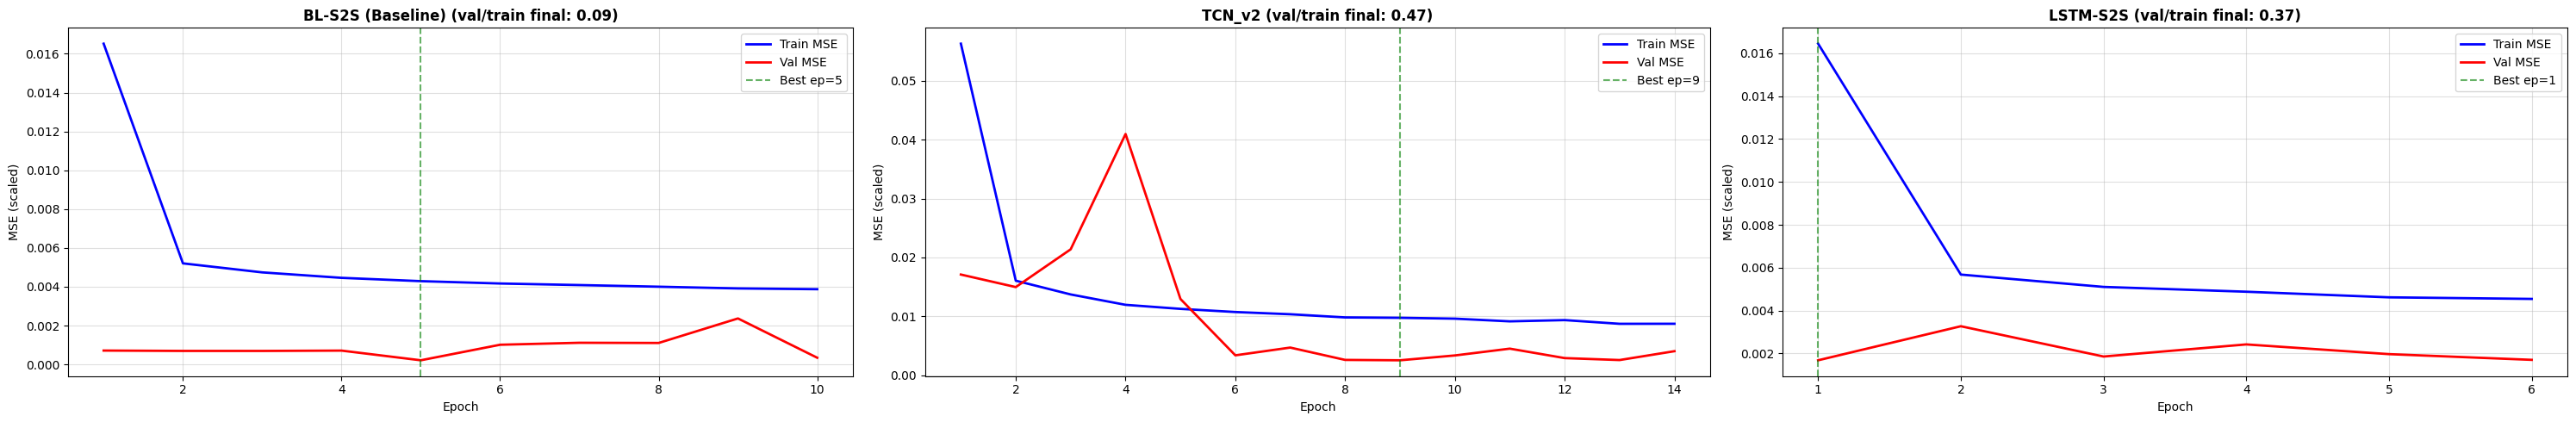

In [ ]:
# ═══════════════════════════════════════════════════════════════
# LEARNING CURVES
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(30, 5))
for ax, res, title in [
    (axes[0], bl_results,  'BL-S2S (Baseline)'),
    (axes[1], tcn_results, 'TCN_v2'),
    (axes[2], s2s_results, 'LSTM-S2S')]:
    ep = range(1, len(res['train']) + 1)
    ax.plot(ep, res['train'], 'b-', label='Train MSE', linewidth=2)
    ax.plot(ep, res['val'],   'r-', label='Val MSE',   linewidth=2)
    ax.axvline(res['best_epoch'], color='green', linestyle='--', alpha=0.6,
               label=f'Best ep={res["best_epoch"]}')
    ax.set_title(f'{title} (val/train final: {res["val"][-1]/res["train"][-1]:.2f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
    ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('learning_curves_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Prediction Visualization

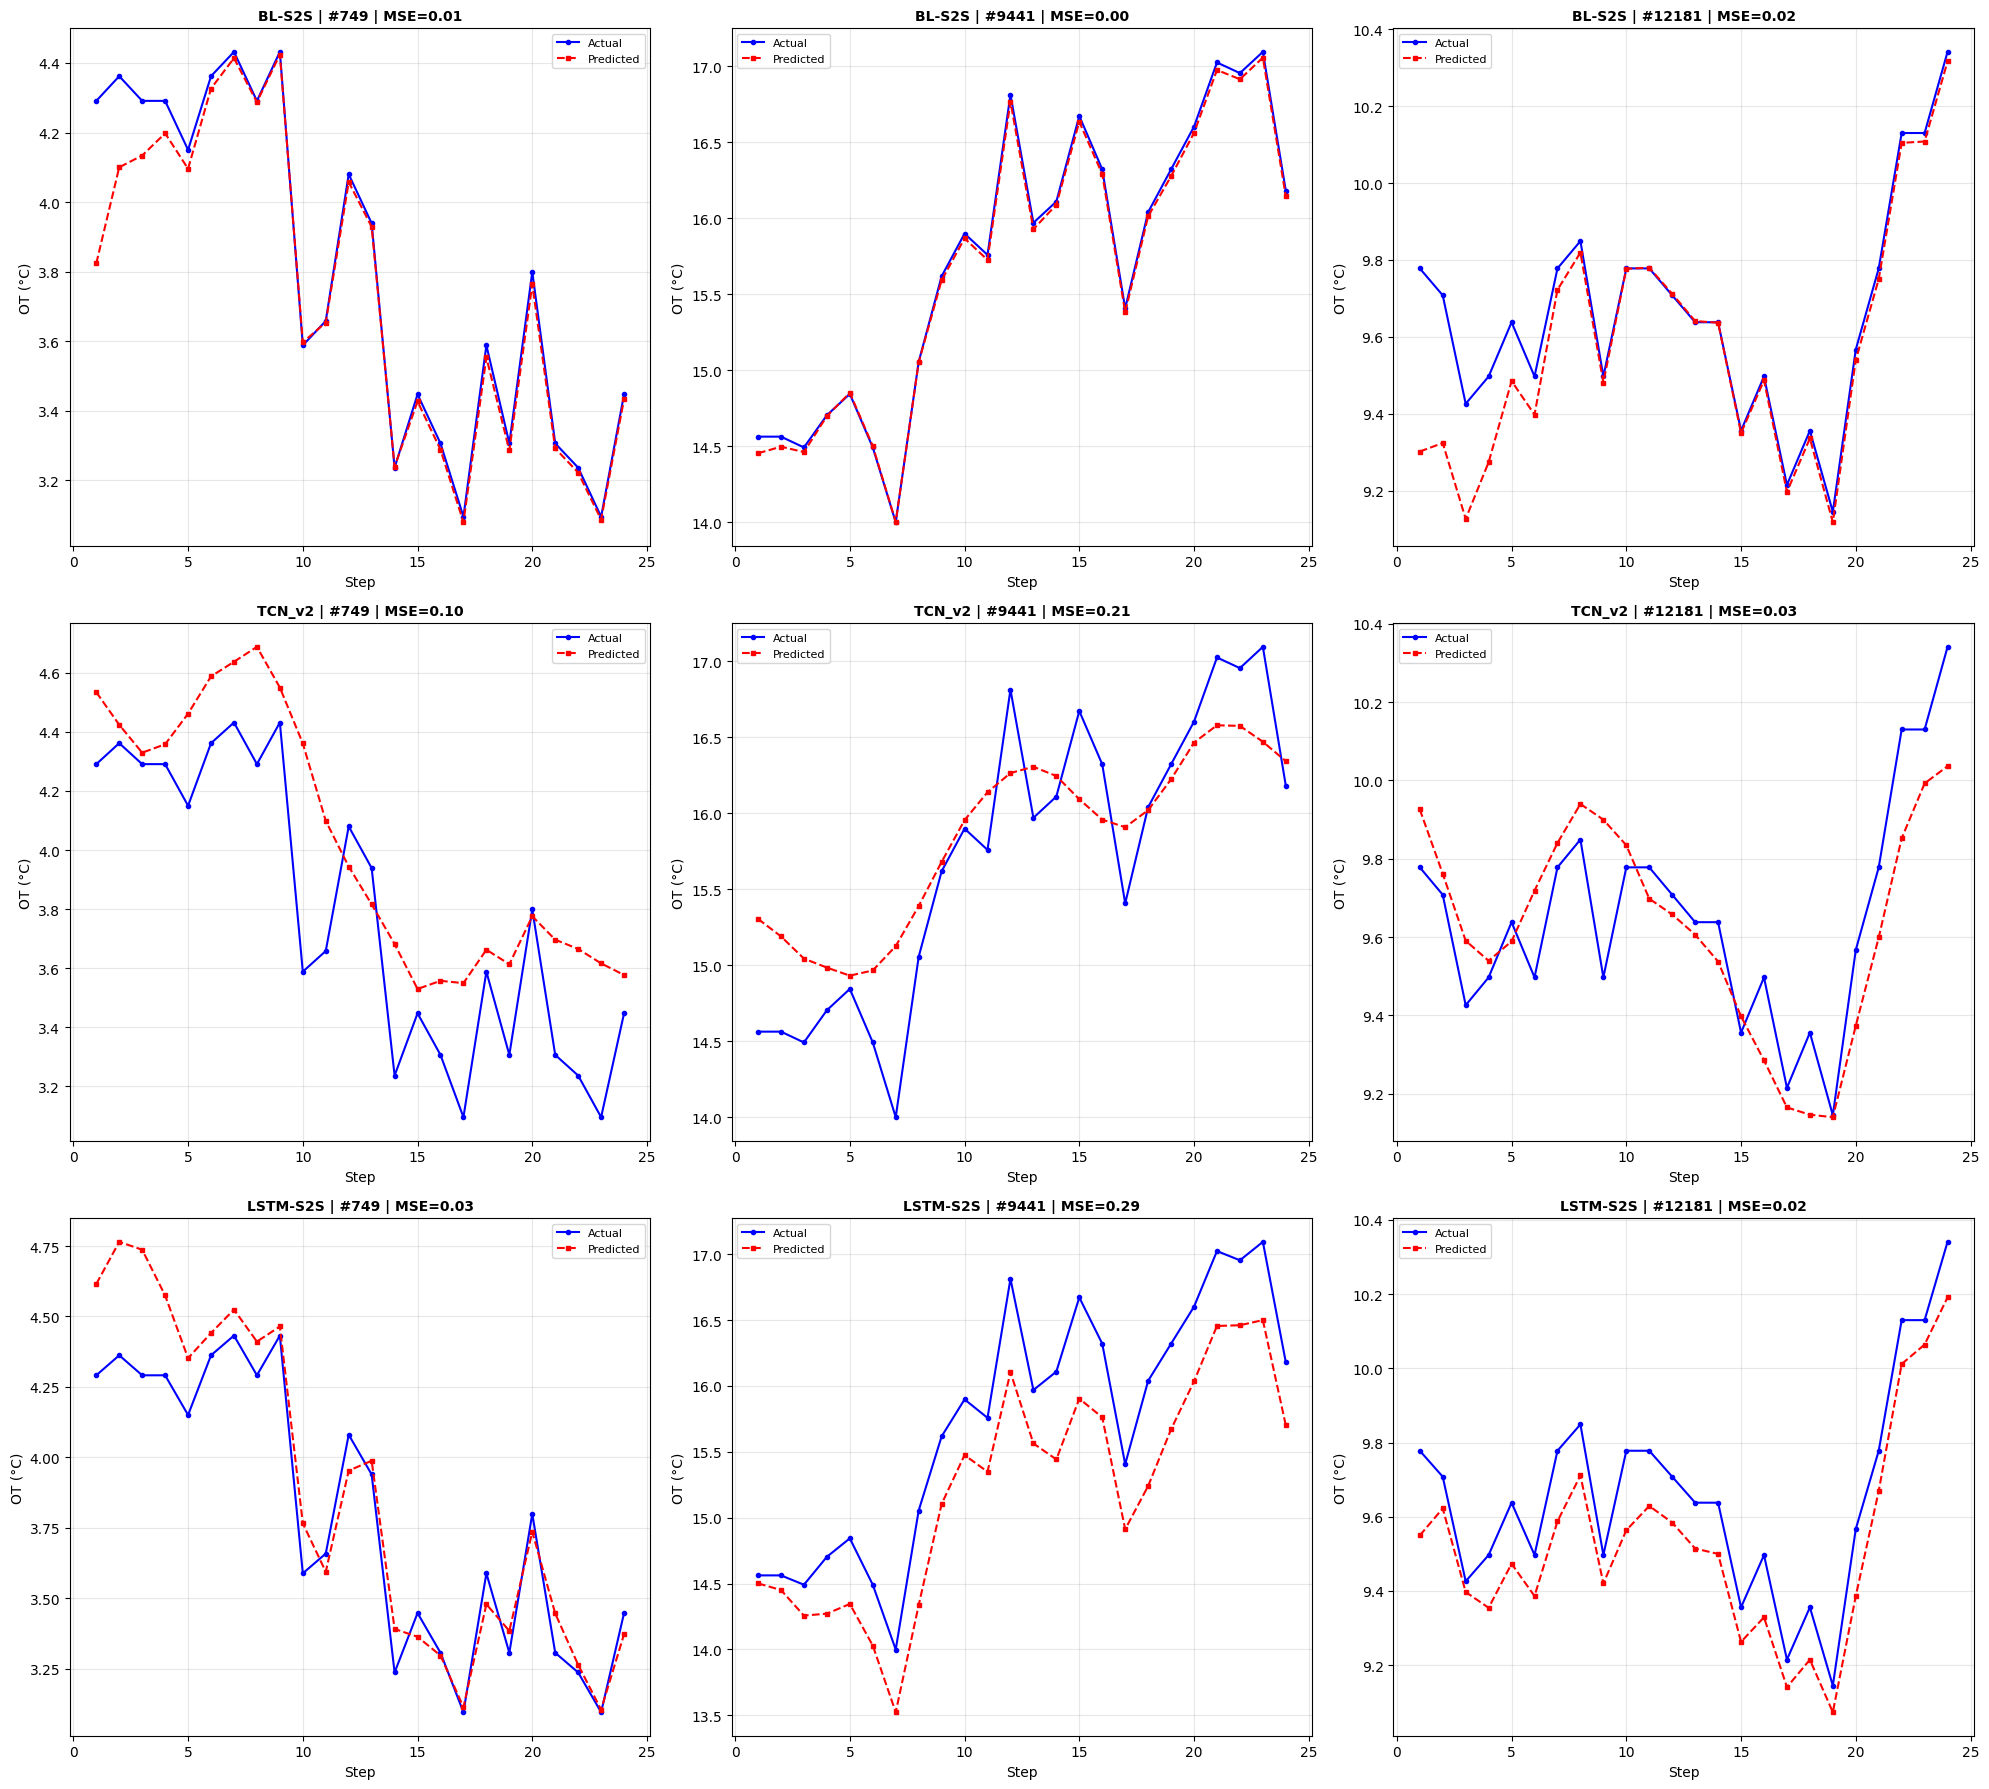

In [ ]:
# ═══════════════════════════════════════════════════════════════
# PREDICTIONS VS ACTUAL
# ═══════════════════════════════════════════════════════════════
np.random.seed(42)
sample_idx = sorted(np.random.choice(len(s2s_preds), 3, replace=False))

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
models = [('BL-S2S', bl_preds, bl_trues),
          ('TCN_v2', tcn_preds, tcn_trues),
          ('LSTM-S2S', s2s_preds, s2s_trues)]
for row, (name, preds, trues) in enumerate(models):
    for col, idx in enumerate(sample_idx):
        ax = axes[row, col]
        steps = range(1, pred_len + 1)
        ax.plot(steps, trues[idx], 'b-o', label='Actual', markersize=3, linewidth=1.5)
        ax.plot(steps, preds[idx], 'r--s', label='Predicted', markersize=3, linewidth=1.5)
        mse_i = np.mean((preds[idx] - trues[idx])**2)
        ax.set_title(f'{name} | #{idx} | MSE={mse_i:.2f}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Step'); ax.set_ylabel('OT (°C)')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Bar Chart Comparison

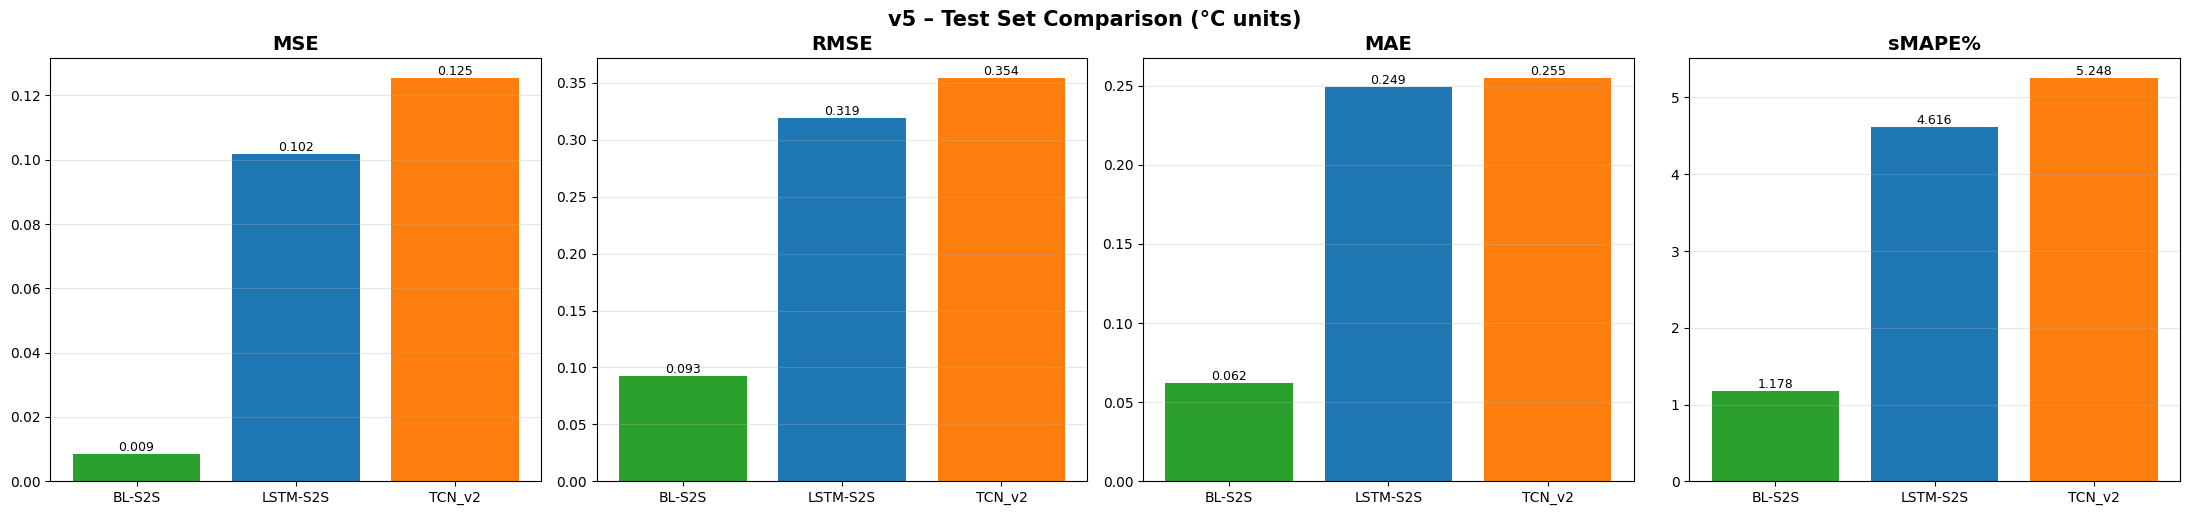


🏆 Best: BL-S2S | MSE=0.0086°C² | RMSE=0.0929°C


In [ ]:
# ═══════════════════════════════════════════════════════════════
# BAR CHART
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
names = ['BL-S2S', 'LSTM-S2S', 'TCN_v2']
colors = ['#2ca02c', '#1f77b4', '#ff7f0e']
for ax, metric in zip(axes, ['MSE', 'RMSE', 'MAE', 'sMAPE%']):
    vals = [bl_m[metric], s2s_m[metric], tcn_m[metric]]
    bars = ax.bar(names, vals, color=colors)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('v5 – Test Set Comparison (°C units)', fontsize=15, fontweight='bold', y=1.02)
plt.savefig('comparison_v9.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best: {best_name} | MSE={best_mse:.4f}°C² | RMSE={np.sqrt(best_mse):.4f}°C')

## 8. Real Data Prediction & Comparison

In [ ]:
# =============================================
# PREDICT ON REAL DATA (test_data.xlsx)
# =============================================
import pandas as pd
import numpy as np

# 1. Load real data
df_real = pd.read_excel('data/test1.xlsx')
df_real['date'] = pd.to_datetime(df_real['date'])
df_real = df_real.set_index('date')

# Drop unused columns if exist
for col in ['MUFL', 'MULL']:
    if col in df_real.columns:
        df_real.drop(col, axis=1, inplace=True)

# Generate time features for real input
df_real = add_time_features(df_real)
df_real['trend'] = apply_trend(df_real, window=period)
df_real['seasonal'] = apply_seasonal(df_real, seasonal_pattern)
df_real['residual'] = (df_real['OT'] - df_real['trend'] - df_real['seasonal']).values
df_real = df_real[train_df.columns] # ensure order

# Scale input sequence
real_scaled = scaler.transform(df_real.values)
Xb_real = torch.tensor(real_scaled, dtype=torch.float32).unsqueeze(0).to(device)

# 2. Load label to compare
df_label = pd.read_excel('data/label1.xlsx')
y_true_actual = df_label['OT'].values

# 3. Construct future covariates for the 24 steps
last_date = df_real.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), periods=pred_len, freq='15min')
df_future = pd.DataFrame(index=future_dates)
df_future['OT'] = y_true_actual  # using actual to align with training distribution
for c in ['HUFL', 'HULL', 'LUFL', 'LULL']:
    df_future[c] = df_real[c].iloc[-1]
df_future = add_time_features(df_future)
combined_df = pd.concat([df_real, df_future])
df_future['trend'] = apply_trend(combined_df, window=period)[-pred_len:]
df_future['seasonal'] = apply_seasonal(df_future, seasonal_pattern)
df_future['residual'] = (df_future['OT'] - df_future['trend'] - df_future['seasonal']).values
df_future = df_future[train_df.columns] # ensure order

future_scaled = scaler.transform(df_future.values)
f_cov_real = torch.tensor(future_scaled[:, -N_COVARIATE:], dtype=torch.float32).unsqueeze(0).to(device)

# 4. Predictions

# --- BL-S2S ---
bl_checkpoint = torch.load("best_bl_s2s.pth", map_location=device, weights_only=False)
bl_model.load_state_dict(bl_checkpoint)
bl_model.eval()
with torch.no_grad():
    y_pred_bl_scaled = bl_model(Xb_real, future_cov=f_cov_real)
y_pred_bl = inverse_target(y_pred_bl_scaled.cpu().numpy()[0], scaler, target_index)

# --- TCN_v2 ---
tcn_checkpoint = torch.load("best_tcn_v9.pth", map_location=device, weights_only=False)
tcn_model.load_state_dict(tcn_checkpoint)
tcn_model.eval()
with torch.no_grad():
    y_pred_tcn_scaled = tcn_model(Xb_real, future_features=f_cov_real)
y_pred_tcn = inverse_target(y_pred_tcn_scaled.cpu().numpy()[0], scaler, target_index)

# --- Seq2Seq ---
s2s_checkpoint = torch.load("best_s2s_v9.pth", map_location=device, weights_only=False)
s2s_model.load_state_dict(s2s_checkpoint)
s2s_model.eval()
with torch.no_grad():
    # Provide dummy y filled with zeros for autoregressive target placeholder
    y_dummy = torch.zeros((1, pred_len)).to(device)
    y_pred_s2s_scaled = s2s_model(Xb_real, y=y_dummy, future_cov=f_cov_real, tf_ratio=0.0)
y_pred_s2s = inverse_target(y_pred_s2s_scaled.cpu().numpy()[0], scaler, target_index)

print('Predictions generated successfully.')

Predictions generated successfully.


=== PERFORMANCE ON ACTUAL DATA (24 STEPS) ===


,MSE,RMSE,MAE,sMAPE%
BL-S2S,0.011838,0.108802,0.087136,0.286844
TCN_v2,0.709850,0.842526,0.739842,2.423070
Seq2SeqLSTM,0.044996,0.212122,0.162964,0.534109


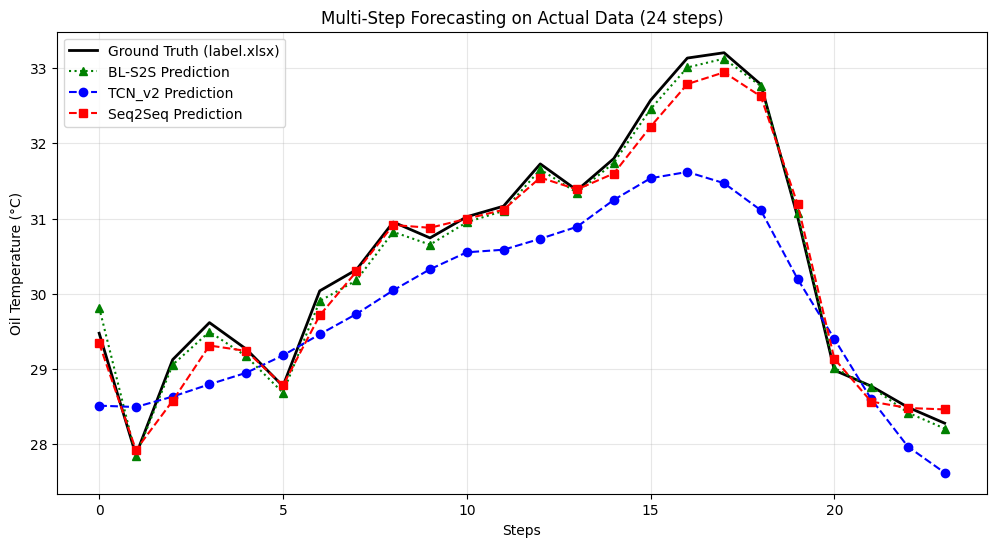

In [ ]:
# =============================================
# COMPARISON ON ACTUAL DATA
# =============================================
metrics_bl_actual = calc_metrics(y_pred_bl, y_true_actual)
metrics_tcn_actual = calc_metrics(y_pred_tcn, y_true_actual)
metrics_s2s_actual = calc_metrics(y_pred_s2s, y_true_actual)

df_comp_actual = pd.DataFrame([metrics_bl_actual, metrics_tcn_actual, metrics_s2s_actual], index=['BL-S2S', 'TCN_v2', 'Seq2SeqLSTM'])
print("=== PERFORMANCE ON ACTUAL DATA (24 STEPS) ===")
display(df_comp_actual)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_true_actual, label='Ground Truth (label.xlsx)', color='black', linewidth=2)
plt.plot(y_pred_bl, label='BL-S2S Prediction', color='green', linestyle=':', marker='^')
plt.plot(y_pred_tcn, label='TCN_v2 Prediction', color='blue', linestyle='--', marker='o')
plt.plot(y_pred_s2s, label='Seq2Seq Prediction', color='red', linestyle='--', marker='s')
plt.title('Multi-Step Forecasting on Actual Data (24 steps)')
plt.xlabel('Steps')
plt.ylabel('Oil Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('actual_prediction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()